In [65]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from iblatlas.atlas import BrainRegions
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from brainbox.task.trials import get_event_aligned_raster, get_psth
from iblatlas.atlas import AllenAtlas
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from brainbox.population.decode import get_spike_counts_in_bins
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox import singlecell
from tqdm.notebook import tqdm
import seaborn as sns

from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox.singlecell import bin_spikes2D
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path
import warnings
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from ibl_info.utils import generate_source_ids
from glob import glob

In [11]:
with open(
    "../data/generated/mifiltered/3bins/selective_decomposition_ACAd_stim_filtered_all_alternate_3.pkl",
    "rb",
) as f:
    acad_data = pkl.load(f)

In [278]:
def compute_rsi(condition):
    rsis = []
    mi = condition["mutual_information"]
    tvm = condition["trivariate"]
    pairs = generate_source_ids(len(mi))
    for idx, pair in enumerate(pairs):
        mi_a = mi[pair[0]]
        mi_b = mi[pair[1]]
        tvm_ab = tvm[idx]
        if tvm_ab < 0:
            # print("skipping")
            # print(mi_a, mi_b)
            continue
        if mi_a < 0:
            mi_a = 0
        if mi_b < 0:
            mi_b = 0
        rsis.append(tvm_ab - (mi_a + mi_b))
    if len(rsis) == 0:
        return 0
    rsis = np.asarray(rsis).reshape(
        -1,
    )
    rsis = np.mean(rsis)
    return rsis

In [279]:
def rsi_region(region_data):
    rsi_congruent = []
    rsi_incongruent = []
    rsi_all = []
    for eid in region_data.keys():
        data = region_data[eid]
        # print("new")
        rsi_all.append(compute_rsi(data["all"]))
        rsi_congruent.append(compute_rsi(data["subsampled"]))
        rsi_incongruent.append(compute_rsi(data["incongruent"]))
    # rsi_incongruent = np.concatenate(rsi_incongruent)
    # rsi_congruent = np.concatenate(rsi_congruent)

    return rsi_incongruent, rsi_congruent, rsi_all

In [280]:
region_data_rsis = {}

In [290]:
files = glob("../data/generated/mifiltered/3bins/*.pkl")

In [291]:
files

['../data/generated/mifiltered/3bins/selective_decomposition_APN_stim_filtered_all_alternate_3.pkl',
 '../data/generated/mifiltered/3bins/selective_decomposition_VPM_stim_filtered_all_alternate_3.pkl',
 '../data/generated/mifiltered/3bins/selective_decomposition_SSp-ul_stim_filtered_all_alternate_3.pkl',
 '../data/generated/mifiltered/3bins/selective_decomposition_PPN_stim_filtered_all_alternate_3.pkl',
 '../data/generated/mifiltered/3bins/selective_decomposition_CUL4 5_stim_filtered_all_alternate_3.pkl',
 '../data/generated/mifiltered/3bins/selective_decomposition_LGd_stim_filtered_all_alternate_3.pkl',
 '../data/generated/mifiltered/3bins/selective_decomposition_IRN_stim_filtered_all_alternate_3.pkl',
 '../data/generated/mifiltered/3bins/selective_decomposition_PL_stim_filtered_all_alternate_3.pkl',
 '../data/generated/mifiltered/3bins/selective_decomposition_PGRN_stim_filtered_all_alternate_3.pkl',
 '../data/generated/mifiltered/3bins/selective_decomposition_MOs_stim_filtered_all_al

In [292]:
for idx in range(len(files)):
    region_name = files[idx].rsplit("_stim_filtered_")[0].rsplit("_")[-1]
    with open(files[idx], "rb") as f:
        data = pkl.load(f)
    rsi_incon, rsi_con, rsi_all = rsi_region(data)
    region_data_rsis[region_name] = {
        "incongruent": np.asanyarray(rsi_incon),
        "congruent": np.asarray(rsi_con),
        "all": np.asarray(rsi_all),
    }

In [293]:
# for region_name in region_data_rsis.keys():
#     fig, ax = plt.subplots(figsize=(5, 5))
#     ax.bar(
#         np.arange(3),
#         [
#             np.mean(region_data_rsis[region_name]["all"]),
#             np.mean(region_data_rsis[region_name]["congruent"]),
#             np.mean(region_data_rsis[region_name]["incongruent"]),
#         ],
#         edgecolor="k",
#         color=["#4D79FF", "#FF4D4D"],
#         alpha=0.75,
#         yerr=[
#             np.std(region_data_rsis[region_name]["all"]) / 2,
#             np.std(region_data_rsis[region_name]["congruent"]) / 2,
#             np.std(region_data_rsis[region_name]["incongruent"] / 2),
#         ],
#         capsize=4,
#     )
#     ax.set_xticks(np.arange(3), ["All", "Congruent", "Incongruent"])
#     ax.set_title(region_name)
#     ax.set_ylabel("RSI")

In [294]:
# combine all together
means_regions = []
for region_name in region_data_rsis.keys():
    means_regions.append(
        [
            np.nanmean(region_data_rsis[region_name]["congruent"]),
            np.nanmean(region_data_rsis[region_name]["incongruent"]),
        ]
    )

In [295]:
means_regions = np.asarray(means_regions)

In [296]:
from scipy.stats import wilcoxon

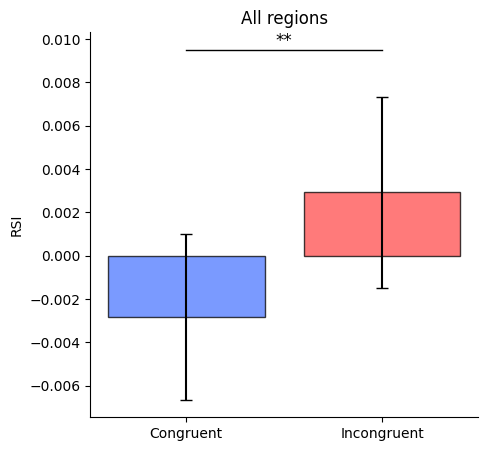

In [297]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(
    np.arange(2),
    [
        np.nanmean(means_regions[:, 0]),
        np.nanmean(means_regions[:, 1]),
    ],
    edgecolor="k",
    color=["#4D79FF", "#FF4D4D"],
    alpha=0.75,
    yerr=[
        np.nanstd(means_regions[:, 0]) / np.sqrt(len(means_regions)),
        np.nanstd(means_regions[:, 1]) / np.sqrt(len(means_regions)),
    ],
    capsize=4,
)

ax.set_xticks(np.arange(2), ["Congruent", "Incongruent"])
ax.set_title("All regions")
ax.set_ylabel("RSI")

a, b = np.mean(means_regions[:, 0]), np.mean(means_regions[:, 1])
c, d = np.std(means_regions[:, 0]) / np.sqrt(len(means_regions)), np.std(
    means_regions[:, 1]
) / np.sqrt(len(means_regions))
x1, x2 = 0, 1  # 0 and 1 correspond to the index of the bars
line_y = np.max([a, b]) + 1.5 * np.max([c, d])  # Position the line above the taller bar

# Plot a horizontal line
plt.plot([x1, x2], [line_y, line_y], color="black", linewidth=1)

# Plot the vertical ticks at the ends of the line

# 3. Display the p-value text
# Set the position for the text
text_x = (x1 + x2) / 2
text_y = line_y
r, p_value = wilcoxon(means_regions[:, 0], means_regions[:, 1])
# Format the p-value for display
if p_value < 0.001:  # type: ignore
    p_value_text = "***"
elif p_value < 0.01:  # type: ignore
    p_value_text = "**"
elif p_value < 0.05:  # type: ignore
    p_value_text = "*"
else:
    p_value_text = "n.s."  # Not significant

plt.text(text_x, text_y, p_value_text, ha="center", va="bottom", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)